# Gene-activity vs. Xenium expression loss evaluation

Compares 4 MOSAICField alignment x assignment conditions:
- **affine + Method A** (nearest-neighbor, 20um cutoff)
- **affine + Method B** (Voronoi, 30um soft filter)
- **nonlinear + Method A**
- **nonlinear + Method B**

Loss = agreement between ArchR `GeneScoreMatrix` gene activity (488B deepseq, 5000bp tiles, log1p)
and pseudobulk Xenium log-normalized expression of cells assigned to each ATAC spot, computed only
on the genes shared between the ArchR GeneScoreMatrix and the Xenium panel.

Inputs (all already produced upstream):
- `mosaicfield_outputs/gene_loss_inputs/` — exported by `export_genescore_for_loss.R`
- `mosaicfield_outputs/r_comparison/` — mapping CSVs + `atac_coords.csv` from `export_for_R.py`
- `mosaicfield_outputs/xenium_affine_aligned.h5ad` — log-normalized Xenium expression


In [1]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmread
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# run_label controls which alignment/mapping source this notebook reads AND where its
# outputs are saved -- "run1" = mosaic_run1_isolated pipeline (free-affine, isolated
# workspace), "run2" = the shared rigid-transform pipeline, "test" = throwaway/exploratory.
run_label = "run1"
if run_label == "run1":
    outdir = "./run1_workspace/mosaicfield_outputs"
else:
    outdir = "./mosaicfield_outputs"

# ArchR GeneScoreMatrix export is keyed by ATAC barcode only (not by alignment), so it's the
# same physical spots regardless of run_label -- always read from the one shared export.
gli_dir = "./mosaicfield_outputs/gene_loss_inputs_v2"  # v2: corrected ArchR project, 11,319 cells
rcmp_dir = os.path.join(outdir, "r_comparison")

# All plots/tables this notebook saves go under <outdir>/gene_loss/<run_label>/, with every
# filename also prefixed by run_label -- keeps run1/run2/test outputs from ever colliding.
gene_loss_outdir = os.path.join(outdir, "gene_loss", run_label)
os.makedirs(gene_loss_outdir, exist_ok=True)
file_prefix = f"{run_label}_"

sns.set_style("whitegrid")


## 1. Load ArchR gene activity (GeneScoreMatrix, shared genes, log1p)

In [2]:
gene_names = pd.read_csv(os.path.join(gli_dir, "archr_gene_names.csv"))["gene"].tolist()
archr_barcodes = pd.read_csv(os.path.join(gli_dir, "archr_barcodes.csv"))["barcode"].tolist()

gs_mat = mmread(os.path.join(gli_dir, "archr_genescore_shared.mtx")).tocsr()  # genes x cells
assert gs_mat.shape == (len(gene_names), len(archr_barcodes))

gene_activity_raw = gs_mat.toarray().T  # cells x genes, raw ArchR gene scores

# Raw version (as before): log1p only, no library-size normalization
gene_activity_log = np.log1p(gene_activity_raw)
gene_activity_df = pd.DataFrame(gene_activity_log, index=archr_barcodes, columns=gene_names)
gene_activity_df.index.name = "barcode"

# Normalized version: total-count normalize each spot to the median spot total (matching
# scanpy's sc.pp.normalize_total default, target_sum=None), then log1p -- this makes ATAC
# gene activity go through the SAME normalization pipeline as the Xenium expression below
# (sc.pp.normalize_total + sc.pp.log1p), so the two are on equivalent footing before scoring.
cell_totals = gene_activity_raw.sum(axis=1)
median_total = np.median(cell_totals[cell_totals > 0])
gene_activity_normed = gene_activity_raw / cell_totals[:, None] * median_total
gene_activity_norm_log = np.log1p(gene_activity_normed)
gene_activity_norm_df = pd.DataFrame(gene_activity_norm_log, index=archr_barcodes, columns=gene_names)
gene_activity_norm_df.index.name = "barcode"

print(f"ArchR gene activity: {gene_activity_df.shape[0]} spots x {gene_activity_df.shape[1]} genes")
print(f"Median per-spot total gene score (normalization target): {median_total:.1f}")


ArchR gene activity: 11319 spots x 377 genes
Median per-spot total gene score (normalization target): 155.5


## 2. Load spot coordinates (affine + nonlinear) and join to ArchR barcodes

In [3]:
atac_coords = pd.read_csv(os.path.join(rcmp_dir, "atac_coords.csv"))
atac_coords["barcode"] = atac_coords["spot_id"].str.split("#").str[-1]

spots = atac_coords.merge(gene_activity_df, on="barcode", how="inner")
spots = spots.set_index("spot_idx", drop=False)

spots_norm = atac_coords.merge(gene_activity_norm_df, on="barcode", how="inner")
spots_norm = spots_norm.set_index("spot_idx", drop=False)

print(f"Spots with both coordinates and ArchR gene activity: {spots.shape[0]} "
      f"(out of {atac_coords.shape[0]} total ATAC spots in the alignment)")

gene_activity_by_idx = spots.set_index("spot_idx")[gene_names]
gene_activity_norm_by_idx = spots_norm.set_index("spot_idx")[gene_names]
coords_by_idx = spots.set_index("spot_idx")[["affine_x", "affine_y", "nonlinear_x", "nonlinear_y"]]


Spots with both coordinates and ArchR gene activity: 11319 (out of 11640 total ATAC spots in the alignment)


## 3. Load Xenium log-normalized expression, subset to shared genes

In [4]:
xenium = ad.read_h5ad(os.path.join(outdir, "xenium_affine_aligned.h5ad"))

xenium_genes_shared = [g for g in gene_names if g in xenium.var_names]
print(f"Shared genes present in BOTH ArchR GeneScoreMatrix and the Xenium h5ad: "
      f"{len(xenium_genes_shared)} / {len(gene_names)}")

xenium_expr = pd.DataFrame(
    xenium[:, xenium_genes_shared].X.toarray(),
    index=xenium.obs_names,
    columns=xenium_genes_shared,
)
xenium_expr.index.name = "xenium_cell"

# Restrict everything downstream to this final shared-gene list
shared_genes = xenium_genes_shared
gene_activity_by_idx = gene_activity_by_idx[shared_genes]
gene_activity_norm_by_idx = gene_activity_norm_by_idx[shared_genes]

# Keep the raw (log1p-only) version around under its own name for the explicit before/after
# comparison below, and make the NORMALIZED version the one everything downstream uses --
# this is what makes ATAC/Xenium normalization equivalent for the correlation scoring.
gene_activity_raw_by_idx = gene_activity_by_idx
gene_activity_by_idx = gene_activity_norm_by_idx

print(f"Final shared gene space used for scoring: {len(shared_genes)} genes")

# Fresh Xenium cell coordinates (for the random null baseline's KNN neighborhoods below) --
# not loaded elsewhere in this notebook, since xenium_expr only carries expression + cell IDs.
xenium_coords_df = pd.read_csv(os.path.join(rcmp_dir, "xenium_coords.csv"))
xenium_coords_df = xenium_coords_df.set_index("cell_id", drop=False)
print(f"Xenium cell coordinates loaded: {xenium_coords_df.shape[0]} cells")

# Precompute a Xenium expression matrix row-aligned to xenium_coords_df's row order, so the
# random-null KNN code below can index by cKDTree position directly (numpy slicing) instead of
# a pandas .reindex() per anchor -- that per-anchor reindex was the actual runtime bottleneck.
xen_expr_aligned = xenium_expr.reindex(xenium_coords_df["cell_id"].values)[shared_genes].to_numpy()


Shared genes present in BOTH ArchR GeneScoreMatrix and the Xenium h5ad: 377 / 377


Final shared gene space used for scoring: 377 genes
Xenium cell coordinates loaded: 60430 cells


### Input matrix units (documented here for future reference)

- **ATAC gene activity** (`gene_activity_by_idx`, `gene_activity_norm_by_idx`): ArchR
  `GeneScoreMatrix` scores per spot per gene (a distance-weighted accessibility score around
  each gene body/promoter, not raw fragment counts). Two versions are carried through this
  notebook:
  - `gene_activity_by_idx` -- **raw** GeneScoreMatrix, `log1p` only (the notebook's original
    behavior).
  - `gene_activity_norm_by_idx` -- GeneScoreMatrix **total-count normalized** per spot to the
    median spot total (matching `scanpy.pp.normalize_total(target_sum=None)`), then `log1p`.
  Both are computed above so the raw-vs-normalized comparison is visible rather than one
  silently overwriting the other; **the normalized version is used everywhere below** so ATAC
  and Xenium go through equivalent preprocessing before correlating.
- **Xenium expression** (`xenium_expr`): loaded from `xenium_affine_aligned.h5ad`, already
  `sc.pp.normalize_total` (default `target_sum=None`) + `sc.pp.log1p` normalized upstream (in
  the alignment notebook's own pipeline, before affine/nonlinear alignment is computed on the
  PCA of this normalized matrix). Same normalization family as the ATAC side above.
- **Coordinate frames**: ATAC has two frames (`affine_x/y`, `nonlinear_x/y`) since only ATAC is
  warped during alignment; Xenium (`xenium_coords_df`, from `xenium_coords.csv`) has a single
  fixed frame, valid for comparison against either ATAC frame.
- This particular execution reads from `run1_workspace/` when `run_label == "run1"` -- i.e. the
  **original** free-affine / eyeballed-scale / manual-crop pipeline (`mosaic_run1.ipynb`), kept
  isolated from the newer rigid-transform ("run2") pipeline's outputs.


## 4. Load the 4 alignment x assignment mapping conditions

In [5]:
mapping_files = {
    "affine_methodA":    ("mapping_affine_nn.csv",       "assigned", True),
    "affine_methodB":     ("mapping_affine_voronoi.csv",  "distant",  False),
    "nonlinear_methodA": ("mapping_nonlinear_nn.csv",    "assigned", True),
    "nonlinear_methodB":  ("mapping_nonlinear_voronoi.csv","distant",  False),
}

mappings = {}
for name, (fname, flag_col, keep_value) in mapping_files.items():
    m = pd.read_csv(os.path.join(rcmp_dir, fname))
    m = m[m[flag_col] == keep_value].copy()
    mappings[name] = m
    print(f"{name:20s}: {m.shape[0]:6d} confidently-assigned cells "
          f"(from {pd.read_csv(os.path.join(rcmp_dir, fname)).shape[0]} total)")


affine_methodA      :  55693 confidently-assigned cells (from 60430 total)
affine_methodB      :  56447 confidently-assigned cells (from 60430 total)


nonlinear_methodA   :  55661 confidently-assigned cells (from 60430 total)


nonlinear_methodB   :  60184 confidently-assigned cells (from 60430 total)


In [6]:
mappings

{'affine_methodA':       xenium_cell  xenium_x_um  xenium_y_um  \
 12     bkcojcik-1  -858.199965   677.553954   
 13     bkcokcgl-1  -853.444805   611.483426   
 14     bkcomjdm-1  -864.760282   637.383562   
 15     bkcomnli-1  -855.984822   662.664632   
 16     bkcpecbl-1  -852.103168   600.437546   
 ...           ...          ...          ...   
 60425  oihjobmd-1 -1037.180994  -427.481085   
 60426  oihjogda-1  -927.221558  -229.992925   
 60427  oihjpojg-1  -972.920000   -50.466307   
 60428  oihkfkco-1  -849.900898  -170.734422   
 60429  oihkflap-1 -1091.561071  -100.188470   
 
                                         atac_spot  atac_spot_idx  distance_um  \
 12     D01942_NG06549_ATv008_1#CTTCCTTGCCTAATCC-1           5484     5.651567   
 13     D01942_NG06549_ATv008_1#ATTCCAGGCCTAATCC-1           3259     9.114929   
 14     D01942_NG06549_ATv008_1#GTTGCATGCCTAATCC-1           7990    12.328083   
 15     D01942_NG06549_ATv008_1#CTTCCTTGCCTAATCC-1           5484    13.4795

## 5. Loss function

For a given assignment, build the pseudobulk Xenium profile per ATAC spot (mean log-expression
across confidently-assigned cells), join to the ArchR gene activity for that spot, and score
agreement on the shared gene space both per-gene (across spots) and per-spot (across genes).


In [7]:
def compute_loss(mapping_df, gene_activity_by_idx, xenium_expr, shared_genes):
    """Returns dict with per-gene df, per-spot df, and summary scalars."""
    m = mapping_df.merge(xenium_expr[shared_genes], left_on="xenium_cell", right_index=True, how="inner")
    pseudobulk = m.groupby("atac_spot_idx")[shared_genes].mean()

    common_idx = pseudobulk.index.intersection(gene_activity_by_idx.index)
    pseudobulk = pseudobulk.loc[common_idx]
    activity = gene_activity_by_idx.loc[common_idx]

    n_spots = len(common_idx)
    if n_spots < 3:
        raise ValueError("Too few spots with both gene activity and assigned cells.")

    # Per-gene correlation (across spots) -- "for all the gene points"
    gene_rows = []
    for g in shared_genes:
        x = activity[g].values
        y = pseudobulk[g].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, spear = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            spear, _ = spearmanr(x, y)
        gene_rows.append((g, pear, spear))
    per_gene = pd.DataFrame(gene_rows, columns=["gene", "pearson", "spearman"]).dropna()

    # Per-spot correlation (across genes) -- spatial diagnostic
    spot_rows = []
    for idx in common_idx:
        x = activity.loc[idx].values
        y = pseudobulk.loc[idx].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, cos = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            cos = cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0, 0]
        spot_rows.append((idx, pear, cos))
    per_spot = pd.DataFrame(spot_rows, columns=["atac_spot_idx", "pearson", "cosine"]).dropna()

    summary = {
        "n_spots": n_spots,
        "median_gene_pearson": per_gene["pearson"].median(),
        "median_gene_spearman": per_gene["spearman"].median(),
        "global_pearson": pearsonr(activity.values.ravel(), pseudobulk.values.ravel())[0],
        "median_spot_pearson": per_spot["pearson"].median(),
    }
    return {"per_gene": per_gene, "per_spot": per_spot, "summary": summary}


## 6. Run the loss function on the 4 baseline conditions

In [8]:
results = {}
for name in mapping_files:
    results[name] = compute_loss(mappings[name], gene_activity_by_idx, xenium_expr, shared_genes)

summary_table = pd.DataFrame({name: r["summary"] for name, r in results.items()}).T
summary_table.index.name = "condition"
summary_table


,n_spots,median_gene_pearson,median_gene_spearman,global_pearson,median_spot_pearson
condition,,,,,
affine_methodA,10986.0,0.013609,0.011467,0.121093,0.119184
affine_methodB,10989.0,0.013789,0.010982,0.121126,0.119257
nonlinear_methodA,11195.0,0.016841,0.013513,0.125817,0.125043
nonlinear_methodB,11210.0,0.016851,0.013589,0.126715,0.125666


In [9]:
# Raw vs normalized ATAC comparison: confirms the two are NOT the same and reports both,
# rather than silently discarding the raw (log1p-only) version.
raw_vs_norm_rows = []
for name in mapping_files:
    r_raw = compute_loss(mappings[name], gene_activity_raw_by_idx, xenium_expr, shared_genes)
    r_norm = results[name]  # already computed against gene_activity_by_idx == normalized
    raw_vs_norm_rows.append({
        "condition": name,
        "median_gene_pearson_raw_log1p": r_raw["summary"]["median_gene_pearson"],
        "median_gene_pearson_normalized": r_norm["summary"]["median_gene_pearson"],
    })
raw_vs_norm_df = pd.DataFrame(raw_vs_norm_rows).set_index("condition")
raw_vs_norm_df["delta"] = raw_vs_norm_df["median_gene_pearson_normalized"] - raw_vs_norm_df["median_gene_pearson_raw_log1p"]
print("ATAC normalization comparison (median per-gene Pearson vs Xenium):")
print(raw_vs_norm_df.round(4))
raw_vs_norm_df.to_csv(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_raw_vs_normalized_atac.csv"))


ATAC normalization comparison (median per-gene Pearson vs Xenium):
                   median_gene_pearson_raw_log1p  \
condition                                          
affine_methodA                            0.0128   
affine_methodB                            0.0130   
nonlinear_methodA                         0.0163   
nonlinear_methodB                         0.0170   

                   median_gene_pearson_normalized   delta  
condition                                                  
affine_methodA                             0.0136  0.0008  
affine_methodB                             0.0138  0.0008  
nonlinear_methodA                          0.0168  0.0005  
nonlinear_methodB                          0.0169 -0.0001  


## 6b. Random null baseline

Pairs each real ATAC spot's gene activity with an *independent, randomly located* Xenium
neighborhood (k=15 nearest cells, capped at 30um), instead of the spot's real assigned cells.
Same per-gene/per-spot Pearson scoring as the 4 real conditions -- this is the "no real spatial
correspondence" floor the 4 real conditions should clear.


In [10]:
def build_random_null_condition(gene_activity_by_idx, xen_expr_aligned, xenium_coords_df, shared_genes,
                                 k=15, max_dist_um=30.0, seed=42):
    """For every real ATAC spot, draw an independent random Xenium anchor location, take its
    k nearest Xenium cells within max_dist_um, and pair the resulting pseudobulk with that
    spot's (unrelated) gene activity. Returns the same per_gene/per_spot/summary shape as
    compute_loss, plus the anchor assignment so the resolution sweep can reuse it unchanged.
    xen_expr_aligned must be row-aligned to xenium_coords_df (numpy array, cells x shared_genes)."""
    rng = np.random.default_rng(seed)
    xen_coords = xenium_coords_df[["x_um", "y_um"]].values
    tree = cKDTree(xen_coords)

    spot_idxs = gene_activity_by_idx.index.values
    anchor_draw = rng.integers(0, len(xen_coords), size=len(spot_idxs))
    anchor_pos = xen_coords[anchor_draw]
    dist, nbr_idx = tree.query(anchor_pos, k=k)

    pseudobulk_rows, kept_spots, kept_anchor_pos = [], [], []
    for i, sidx in enumerate(spot_idxs):
        d, nb = dist[i], nbr_idx[i]
        mask = d <= max_dist_um
        if mask.sum() < 2:
            continue
        pseudobulk_rows.append(xen_expr_aligned[nb[mask]].mean(axis=0))
        kept_spots.append(sidx)
        kept_anchor_pos.append(anchor_pos[i])

    pseudobulk = pd.DataFrame(pseudobulk_rows, index=kept_spots, columns=shared_genes)
    activity = gene_activity_by_idx.loc[kept_spots]
    n_spots = len(kept_spots)

    gene_rows = []
    for g in shared_genes:
        x, y = activity[g].values, pseudobulk[g].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, spear = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            spear, _ = spearmanr(x, y)
        gene_rows.append((g, pear, spear))
    per_gene = pd.DataFrame(gene_rows, columns=["gene", "pearson", "spearman"]).dropna()

    spot_rows = []
    for sidx in kept_spots:
        x = activity.loc[sidx].values
        y = pseudobulk.loc[sidx].values
        if np.std(x) == 0 or np.std(y) == 0:
            pear, cos = np.nan, np.nan
        else:
            pear, _ = pearsonr(x, y)
            cos = cosine_similarity(x.reshape(1, -1), y.reshape(1, -1))[0, 0]
        spot_rows.append((sidx, pear, cos))
    per_spot = pd.DataFrame(spot_rows, columns=["atac_spot_idx", "pearson", "cosine"]).dropna()

    summary = {
        "n_spots": n_spots,
        "median_gene_pearson": per_gene["pearson"].median(),
        "median_gene_spearman": per_gene["spearman"].median(),
        "global_pearson": pearsonr(activity.values.ravel(), pseudobulk.values.ravel())[0],
        "median_spot_pearson": per_spot["pearson"].median(),
    }
    anchors = pd.Series([tuple(p) for p in kept_anchor_pos], index=kept_spots, name="anchor_xy")
    return {"per_gene": per_gene, "per_spot": per_spot, "summary": summary, "anchors": anchors}


results["random_null"] = build_random_null_condition(
    gene_activity_by_idx, xen_expr_aligned, xenium_coords_df, shared_genes, k=15, max_dist_um=30.0, seed=42
)
print("Random null baseline (native resolution):")
print(pd.Series(results["random_null"]["summary"]))


Random null baseline (native resolution):
n_spots                 11318.000000
median_gene_pearson         0.000117
median_gene_spearman        0.000986
global_pearson              0.113677
median_spot_pearson         0.110372
dtype: float64


In [11]:
per_gene_long = pd.concat(
    [r["per_gene"].assign(condition=name) for name, r in results.items()],
    ignore_index=True,
)
per_spot_long = pd.concat(
    [r["per_spot"].assign(condition=name) for name, r in results.items()],
    ignore_index=True,
)
per_gene_long.head()


,gene,pearson,spearman,condition
0,MTOR,0.013122,0.011682,affine_methodA
1,C1QA,-0.005458,-0.004980,affine_methodA
2,C1QC,0.003236,-0.003379,affine_methodA
3,TRAPPC3,0.003102,0.009960,affine_methodA
4,SMAP2,0.042590,0.045748,affine_methodA


## 7. Multi-resolution sweep

Bin ATAC spots into square spatial grid cells of increasing size (in um), aggregating gene
activity (sum) and re-pooling assigned Xenium cells per bin, then rescoring.


In [12]:
def assign_grid_bin(x, y, bin_size):
    return (np.floor(x / bin_size).astype(int).astype(str) + "_" +
            np.floor(y / bin_size).astype(int).astype(str))

def compute_loss_at_resolution(mapping_df, gene_activity_by_idx, coords_by_idx,
                                xenium_expr, shared_genes, bin_size, coord_cols):
    xcol, ycol = coord_cols
    bins = assign_grid_bin(coords_by_idx[xcol].values, coords_by_idx[ycol].values, bin_size)
    spot_to_bin = pd.Series(bins, index=coords_by_idx.index, name="bin_id")

    activity_binned = gene_activity_by_idx.groupby(spot_to_bin).sum()

    m = mapping_df.merge(xenium_expr[shared_genes], left_on="xenium_cell", right_index=True, how="inner")
    m = m.merge(spot_to_bin.rename("bin_id"), left_on="atac_spot_idx", right_index=True, how="inner")
    pseudobulk_binned = m.groupby("bin_id")[shared_genes].mean()

    common_bins = activity_binned.index.intersection(pseudobulk_binned.index)
    activity_binned = activity_binned.loc[common_bins]
    pseudobulk_binned = pseudobulk_binned.loc[common_bins]

    # How many original ATAC spots and assigned Xenium cells actually fed into these bins
    n_atac_spots = spot_to_bin[spot_to_bin.isin(common_bins)].shape[0]
    n_xenium_cells = m[m["bin_id"].isin(common_bins)].shape[0]

    if len(common_bins) < 3:
        return {"n_bins": len(common_bins), "n_atac_spots": n_atac_spots, "n_xenium_cells": n_xenium_cells,
                "mean_gene_pearson": np.nan, "median_gene_pearson": np.nan, "global_pearson": np.nan}

    pears = []
    for g in shared_genes:
        x, y = activity_binned[g].values, pseudobulk_binned[g].values
        if np.std(x) > 0 and np.std(y) > 0:
            pears.append(pearsonr(x, y)[0])
    return {
        "n_bins": len(common_bins),
        "n_atac_spots": n_atac_spots,
        "n_xenium_cells": n_xenium_cells,
        "mean_gene_pearson": np.nanmean(pears) if pears else np.nan,
        "median_gene_pearson": np.nanmedian(pears) if pears else np.nan,
        "global_pearson": pearsonr(activity_binned.values.ravel(), pseudobulk_binned.values.ravel())[0],
    }

def compute_null_loss_at_resolution(gene_activity_by_idx, anchors, xen_expr_aligned, xenium_coords_df,
                                     shared_genes, radius_um):
    """Resolution sweep for the random null: reuses the SAME per-spot anchor locations from
    build_random_null_condition (not re-randomized) but grows the Xenium aggregation radius
    around each anchor to match bin_size, exactly like the real conditions pool more Xenium
    cells at coarser resolution. xen_expr_aligned must be row-aligned to xenium_coords_df."""
    xen_coords = xenium_coords_df[["x_um", "y_um"]].values
    tree = cKDTree(xen_coords)

    spot_idxs = anchors.index.values
    anchor_pos = np.array(anchors.tolist())
    nbr_lists = tree.query_ball_point(anchor_pos, r=radius_um)

    pseudobulk_rows, kept_spots, n_xenium_cells = [], [], 0
    for sidx, nb in zip(spot_idxs, nbr_lists):
        if len(nb) < 2:
            continue
        pseudobulk_rows.append(xen_expr_aligned[nb].mean(axis=0))
        kept_spots.append(sidx)
        n_xenium_cells += len(nb)

    if len(kept_spots) < 3:
        return {"n_bins": len(kept_spots), "n_atac_spots": len(kept_spots), "n_xenium_cells": n_xenium_cells,
                "mean_gene_pearson": np.nan, "median_gene_pearson": np.nan, "global_pearson": np.nan}

    pseudobulk = pd.DataFrame(pseudobulk_rows, index=kept_spots, columns=shared_genes)
    activity = gene_activity_by_idx.loc[kept_spots]
    pears = []
    for g in shared_genes:
        x, y = activity[g].values, pseudobulk[g].values
        if np.std(x) > 0 and np.std(y) > 0:
            pears.append(pearsonr(x, y)[0])
    return {
        "n_bins": len(kept_spots),
        "n_atac_spots": len(kept_spots),
        "n_xenium_cells": n_xenium_cells,
        "mean_gene_pearson": np.nanmean(pears) if pears else np.nan,
        "median_gene_pearson": np.nanmedian(pears) if pears else np.nan,
        "global_pearson": pearsonr(activity.values.ravel(), pseudobulk.values.ravel())[0],
    }

# Extended out to 1000um (from the original 400um cap) to see where correlation plateaus
resolutions_um = [0, 25, 50, 100, 200, 400, 600, 800, 1000]  # 0 = native spot resolution
coord_cols_for = {
    "affine_methodA": ("affine_x", "affine_y"),
    "affine_methodB": ("affine_x", "affine_y"),
    "nonlinear_methodA": ("nonlinear_x", "nonlinear_y"),
    "nonlinear_methodB": ("nonlinear_x", "nonlinear_y"),
}

resolution_rows = []
for name in mapping_files:
    for res in resolutions_um:
        if res == 0:
            s = results[name]["summary"]
            n_xenium_cells_native = mappings[name].merge(
                gene_activity_by_idx[[]], left_on="atac_spot_idx", right_index=True, how="inner"
            ).shape[0]
            row = {"n_bins": s["n_spots"], "n_atac_spots": s["n_spots"],
                   "n_xenium_cells": n_xenium_cells_native,
                   "mean_gene_pearson": results[name]["per_gene"]["pearson"].mean(),
                   "median_gene_pearson": s["median_gene_pearson"],
                   "global_pearson": s["global_pearson"]}
        else:
            row = compute_loss_at_resolution(
                mappings[name], gene_activity_by_idx, coords_by_idx,
                xenium_expr, shared_genes, res, coord_cols_for[name],
            )
        resolution_rows.append({"condition": name, "resolution_um": res, **row})

# Random null resolution sweep -- same anchors throughout, radius grown to match each bin size
# (native resolution reuses the k=15/30um result already computed above)
null_anchors = results["random_null"]["anchors"]
for res in resolutions_um:
    if res == 0:
        s = results["random_null"]["summary"]
        row = {"n_bins": s["n_spots"], "n_atac_spots": s["n_spots"],
               "n_xenium_cells": len(null_anchors) * 15,  # approx: k=15 per anchor at native res
               "mean_gene_pearson": results["random_null"]["per_gene"]["pearson"].mean(),
               "median_gene_pearson": s["median_gene_pearson"],
               "global_pearson": s["global_pearson"]}
    else:
        row = compute_null_loss_at_resolution(
            gene_activity_by_idx, null_anchors, xen_expr_aligned, xenium_coords_df, shared_genes, radius_um=res
        )
    resolution_rows.append({"condition": "random_null", "resolution_um": res, **row})

resolution_df = pd.DataFrame(resolution_rows)
resolution_df


,condition,resolution_um,n_bins,n_atac_spots,n_xenium_cells,mean_gene_pearson,median_gene_pearson,global_pearson
0,affine_methodA,0,10986,10986,54631,0.021700,0.013609,0.121093
1,affine_methodA,25,10986,10986,54631,0.021700,0.013609,0.121093
2,affine_methodA,50,4613,11106,54631,0.021433,0.013553,0.123375
3,affine_methodA,100,1219,11206,54631,0.052925,0.038108,0.168898
4,affine_methodA,200,333,11262,54631,0.070036,0.063872,0.168551
5,affine_methodA,400,92,11274,54631,0.059530,0.039549,0.154911
6,affine_methodA,600,48,11292,54631,0.055705,0.075018,0.148585
7,affine_methodA,800,31,11307,54631,0.057518,0.040031,0.121565
8,affine_methodA,1000,22,11319,54631,0.054614,0.040854,0.111758
9,affine_methodB,0,10989,10989,55250,0.021681,0.013789,0.121126


In [13]:
# Counts table: how many (aggregated) ATAC spot-groups and assigned Xenium cells feed each
# resolution's correlation, per condition -- coarser bins average over more spots/cells,
# so this contextualizes why correlation tends to rise with bin size.
counts_pivot_bins = resolution_df.pivot(index="condition", columns="resolution_um", values="n_bins")
counts_pivot_atac = resolution_df.pivot(index="condition", columns="resolution_um", values="n_atac_spots")
counts_pivot_xenium = resolution_df.pivot(index="condition", columns="resolution_um", values="n_xenium_cells")

print("Number of spatial bins (aggregated ATAC spot-groups) per condition x resolution_um:")
print(counts_pivot_bins.astype("Int64"))
print("\nTotal original ATAC spots contributing per condition x resolution_um:")
print(counts_pivot_atac.astype("Int64"))
print("\nTotal assigned Xenium cells contributing per condition x resolution_um:")
print(counts_pivot_xenium.astype("Int64"))

counts_pivot_bins.to_csv(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_resolution_counts_bins.csv"))
counts_pivot_atac.to_csv(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_resolution_counts_atac_spots.csv"))
counts_pivot_xenium.to_csv(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_resolution_counts_xenium_cells.csv"))


Number of spatial bins (aggregated ATAC spot-groups) per condition x resolution_um:
resolution_um       0      25     50     100    200    400    600    800   \
condition                                                                   
affine_methodA     10986  10986   4613   1219    333     92     48     31   
affine_methodB     10989  10989   4615   1220    333     92     48     31   
nonlinear_methodA  11195  11132   4927   1299    355     98     49     35   
nonlinear_methodB  11210  11146   4931   1299    355     98     49     35   
random_null        11318  11315  11318  11318  11318  11318  11318  11318   

resolution_um       1000  
condition                 
affine_methodA        22  
affine_methodB        22  
nonlinear_methodA     21  
nonlinear_methodB     21  
random_null        11318  

Total original ATAC spots contributing per condition x resolution_um:
resolution_um       0      25     50     100    200    400    600    800   \
condition                              

In [14]:
resolution_pivot_mean = resolution_df.pivot(index="condition", columns="resolution_um", values="mean_gene_pearson")
resolution_pivot_median = resolution_df.pivot(index="condition", columns="resolution_um", values="median_gene_pearson")

print("Mean per-gene Pearson (condition x resolution_um):")
print(resolution_pivot_mean.round(4))
print("\nMedian per-gene Pearson (condition x resolution_um):")
print(resolution_pivot_median.round(4))


Mean per-gene Pearson (condition x resolution_um):
resolution_um        0       25      50      100     200     400     600   \
condition                                                                   
affine_methodA     0.0217  0.0217  0.0214  0.0529  0.0700  0.0595  0.0557   
affine_methodB     0.0217  0.0217  0.0213  0.0529  0.0694  0.0575  0.0567   
nonlinear_methodA  0.0281  0.0283  0.0290  0.0590  0.0694  0.0818  0.0474   
nonlinear_methodB  0.0286  0.0288  0.0297  0.0596  0.0692  0.0806  0.0536   
random_null        0.0004  0.0007  0.0006  0.0004  0.0005  0.0005  0.0005   

resolution_um        800     1000  
condition                          
affine_methodA     0.0575  0.0546  
affine_methodB     0.0566  0.0563  
nonlinear_methodA  0.0906  0.0210  
nonlinear_methodB  0.0885  0.0193  
random_null        0.0007  0.0008  

Median per-gene Pearson (condition x resolution_um):
resolution_um        0       25      50      100     200     400     600   \
condition                 

## 8. Plots

In [15]:
# Consistent colors across all plots
COND_COLORS = {
    "random_null":       "#999999",  # grey -- null baseline
    "affine_methodA":    "#7ab8e8",  # light blue
    "affine_methodB":    "#1a6bbd",  # dark blue
    "nonlinear_methodA": "#f5a363",  # light orange
    "nonlinear_methodB": "#c0390b",  # dark red-orange
}
COND_ORDER = ["random_null", "affine_methodA", "affine_methodB", "nonlinear_methodA", "nonlinear_methodB"]


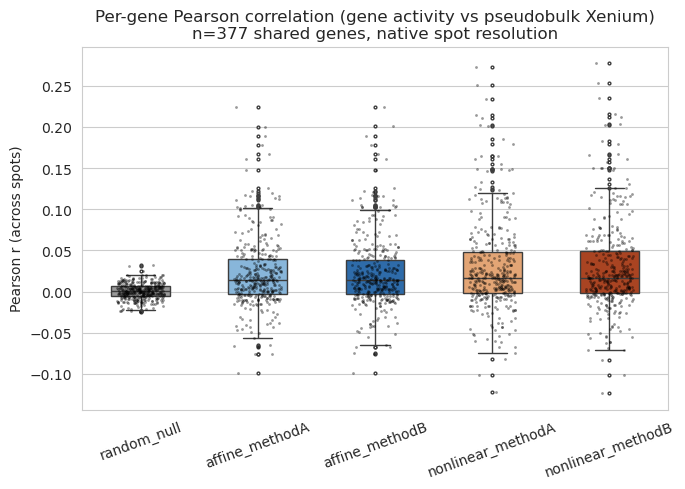

In [16]:
# Plot 1: per-gene Pearson correlation distribution, one box per condition (native resolution)
fig, ax = plt.subplots(figsize=(7, 5))
order = COND_ORDER
sns.boxplot(data=per_gene_long, x="condition", y="pearson", order=order, hue="condition", ax=ax,
            palette=COND_COLORS, width=0.5, fliersize=2, legend=False)
sns.stripplot(data=per_gene_long, x="condition", y="pearson", order=order, ax=ax,
              color="black", size=2, alpha=0.4, jitter=0.2)
ax.set_title(f"Per-gene Pearson correlation (gene activity vs pseudobulk Xenium)\n"
             f"n={len(shared_genes)} shared genes, native spot resolution")
ax.set_ylabel("Pearson r (across spots)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_plot1_per_gene_pearson_boxplot.png"), dpi=150)
plt.show()


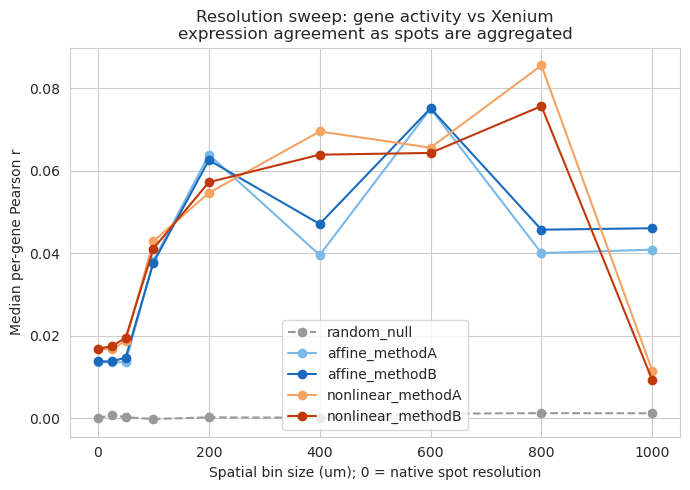

In [17]:
# Plot 2: resolution sweep -- median per-gene Pearson vs grid bin size, one line per condition
fig, ax = plt.subplots(figsize=(7, 5))
for name in order:
    sub = resolution_df[resolution_df["condition"] == name]
    style = dict(linestyle="--") if name == "random_null" else {}
    ax.plot(sub["resolution_um"], sub["median_gene_pearson"], marker="o", color=COND_COLORS[name], label=name, **style)
ax.set_xlabel("Spatial bin size (um); 0 = native spot resolution")
ax.set_ylabel("Median per-gene Pearson r")
ax.set_title("Resolution sweep: gene activity vs Xenium\nexpression agreement as spots are aggregated")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_plot2_resolution_sweep.png"), dpi=150)
plt.show()


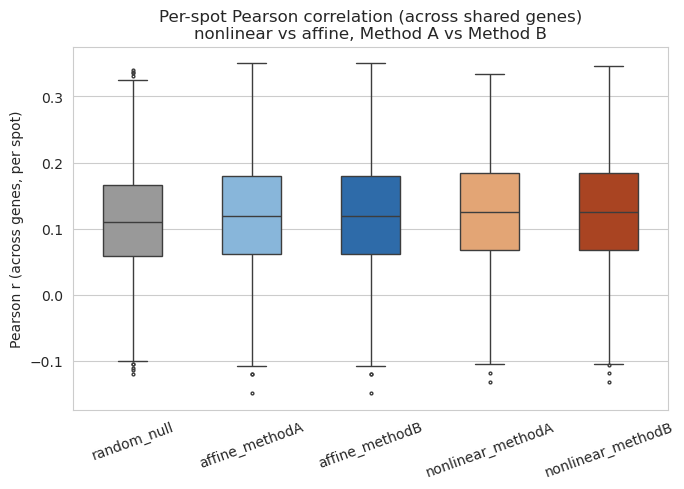

In [18]:
# Plot 3: per-spot Pearson correlation, affine vs nonlinear, faceted by assignment method
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=per_spot_long, x="condition", y="pearson", order=order, hue="condition", ax=ax,
            palette=COND_COLORS, width=0.5, fliersize=2, legend=False)
ax.set_title("Per-spot Pearson correlation (across shared genes)\nnonlinear vs affine, Method A vs Method B")
ax.set_ylabel("Pearson r (across genes, per spot)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_plot3_per_spot_pearson_boxplot.png"), dpi=150)
plt.show()


## 8b. Method B (Voronoi + soft filter) vs Method A (NN cutoff): head-to-head

Fixing alignment to nonlinear (the better alignment from above), directly compare the two
assignment methods on the *same* spots/genes: coverage (how many cells get used at all),
assignment precision (mean distance), and paired score differences (so ties where both
methods agree don't dilute the comparison).

In [19]:
def paired_method_comparison(name_a, name_b, mapping_files, gene_activity_by_idx, xenium_expr, shared_genes):
    raw_a = pd.read_csv(os.path.join(rcmp_dir, mapping_files[name_a][0]))
    raw_b = pd.read_csv(os.path.join(rcmp_dir, mapping_files[name_b][0]))

    coverage = pd.DataFrame({
        name_a: {
            "cells_kept": mappings[name_a].shape[0],
            "cells_total": raw_a.shape[0],
            "pct_cells_kept": 100 * mappings[name_a].shape[0] / raw_a.shape[0],
            "mean_cells_per_spot": mappings[name_a].groupby("atac_spot_idx").size().mean(),
            "mean_assign_dist_um": mappings[name_a]["distance_um"].mean(),
        },
        name_b: {
            "cells_kept": mappings[name_b].shape[0],
            "cells_total": raw_b.shape[0],
            "pct_cells_kept": 100 * mappings[name_b].shape[0] / raw_b.shape[0],
            "mean_cells_per_spot": mappings[name_b].groupby("atac_spot_idx").size().mean(),
            "mean_assign_dist_um": mappings[name_b]["distance_um"].mean(),
        },
    }).T
    return coverage

coverage_table = paired_method_comparison(
    "nonlinear_methodA", "nonlinear_methodB", mapping_files, gene_activity_by_idx, xenium_expr, shared_genes
)
coverage_table.round(2)


,cells_kept,cells_total,pct_cells_kept,mean_cells_per_spot,mean_assign_dist_um
nonlinear_methodA,55661.0,60430.0,92.11,4.84,12.09
nonlinear_methodB,60184.0,60430.0,99.59,5.23,12.85


In [20]:
# Paired per-gene and per-spot differences (Method B - Method A), nonlinear alignment fixed
pg_a = results["nonlinear_methodA"]["per_gene"].set_index("gene")
pg_b = results["nonlinear_methodB"]["per_gene"].set_index("gene")
paired_genes = pg_a[["pearson"]].join(pg_b[["pearson"]], lsuffix="_A", rsuffix="_B").dropna()
gene_diff = paired_genes["pearson_B"] - paired_genes["pearson_A"]

ps_a = results["nonlinear_methodA"]["per_spot"].set_index("atac_spot_idx")
ps_b = results["nonlinear_methodB"]["per_spot"].set_index("atac_spot_idx")
common_spots = ps_a.index.intersection(ps_b.index)
paired_spots = ps_a.loc[common_spots, ["pearson"]].join(
    ps_b.loc[common_spots, ["pearson"]], lsuffix="_A", rsuffix="_B"
)
spot_diff = paired_spots["pearson_B"] - paired_spots["pearson_A"]

from scipy.stats import wilcoxon
gene_stat, gene_p = wilcoxon(paired_genes["pearson_B"], paired_genes["pearson_A"])
spot_stat, spot_p = wilcoxon(paired_spots["pearson_B"], paired_spots["pearson_A"])

paired_summary = pd.DataFrame({
    "per_gene (n=377)": {
        "mean_diff_B_minus_A": gene_diff.mean(), "median_diff_B_minus_A": gene_diff.median(),
        "frac_B_better": (gene_diff > 0).mean(), "wilcoxon_p": gene_p,
    },
    "per_spot (n=%d)" % len(common_spots): {
        "mean_diff_B_minus_A": spot_diff.mean(), "median_diff_B_minus_A": spot_diff.median(),
        "frac_B_better": (spot_diff > 0).mean(), "wilcoxon_p": spot_p,
    },
}).T
paired_summary.round(4)


,mean_diff_B_minus_A,median_diff_B_minus_A,frac_B_better,wilcoxon_p
per_gene (n=377),0.0005,0.0005,0.6127,0.0
per_spot (n=11195),0.0009,0.0000,0.1718,0.0


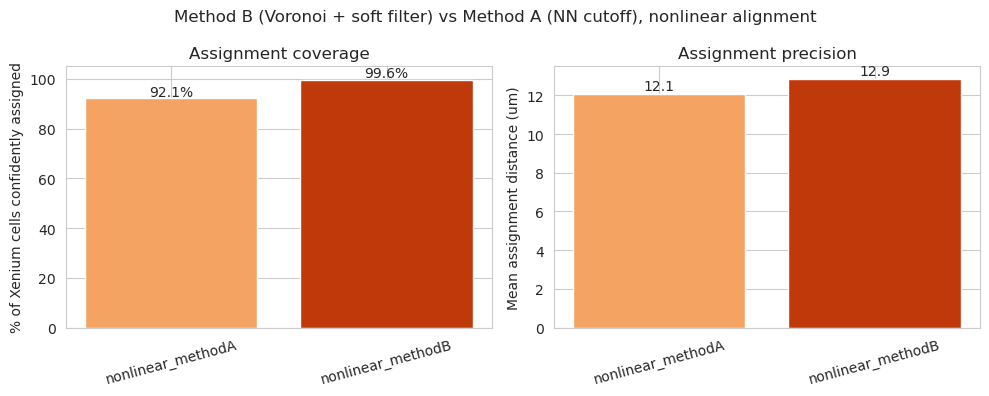

In [21]:
# Plot 4: cell coverage (% of cells confidently assigned) -- shows Method B keeps far more cells
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(coverage_table.index, coverage_table["pct_cells_kept"], color=[COND_COLORS["nonlinear_methodA"], COND_COLORS["nonlinear_methodB"]])
axes[0].set_ylabel("% of Xenium cells confidently assigned")
axes[0].set_title("Assignment coverage")
axes[0].set_ylim(0, 105)
for i, v in enumerate(coverage_table["pct_cells_kept"]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")

axes[1].bar(coverage_table.index, coverage_table["mean_assign_dist_um"], color=[COND_COLORS["nonlinear_methodA"], COND_COLORS["nonlinear_methodB"]])
axes[1].set_ylabel("Mean assignment distance (um)")
axes[1].set_title("Assignment precision")
for i, v in enumerate(coverage_table["mean_assign_dist_um"]):
    axes[1].text(i, v + 0.2, f"{v:.1f}", ha="center")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Method B (Voronoi + soft filter) vs Method A (NN cutoff), nonlinear alignment")
fig.tight_layout()
fig.savefig(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_plot4_coverage_precision.png"), dpi=150)
plt.show()


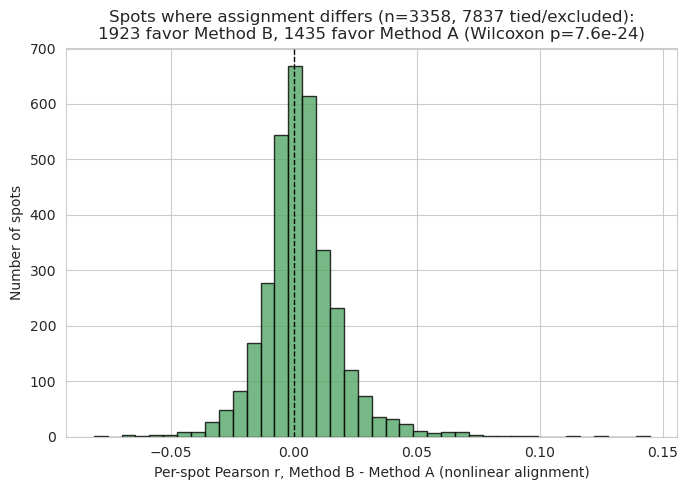

In [22]:
# Plot 5: paired per-spot score difference (Method B - Method A) -- most spots tie (same cells
# assigned by both methods), but among spots where the methods disagree, B skews positive.
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(spot_diff[spot_diff != 0], bins=40, color="#55A868", edgecolor="black", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Per-spot Pearson r, Method B - Method A (nonlinear alignment)")
ax.set_ylabel("Number of spots")
n_tied = (spot_diff == 0).sum()
n_pos = (spot_diff > 0).sum()
n_neg = (spot_diff < 0).sum()
ax.set_title(
    f"Spots where assignment differs (n={n_pos + n_neg}, {n_tied} tied/excluded):\n"
    f"{n_pos} favor Method B, {n_neg} favor Method A (Wilcoxon p={spot_p:.1e})"
)
fig.tight_layout()
fig.savefig(os.path.join(gene_loss_outdir, f"{file_prefix}gene_loss_plot5_methodB_vs_A_paired_diff.png"), dpi=150)
plt.show()


## 9. Summary

In [23]:
print("Summary score per condition (native resolution):")
print(summary_table[["n_spots", "median_gene_pearson", "median_gene_spearman", "global_pearson"]])

best = summary_table["median_gene_pearson"].astype(float).idxmax()
print(f"\nBest condition by median per-gene Pearson: {best}")


Summary score per condition (native resolution):
                   n_spots  median_gene_pearson  median_gene_spearman  \
condition                                                               
affine_methodA     10986.0             0.013609              0.011467   
affine_methodB     10989.0             0.013789              0.010982   
nonlinear_methodA  11195.0             0.016841              0.013513   
nonlinear_methodB  11210.0             0.016851              0.013589   

                   global_pearson  
condition                          
affine_methodA           0.121093  
affine_methodB           0.121126  
nonlinear_methodA        0.125817  
nonlinear_methodB        0.126715  

Best condition by median per-gene Pearson: nonlinear_methodB
